In case an NVIDIA GPU is available on your machine, we recommend to install CUDA. **Do not execute this, if you do not have such a GPU!**

```sh
pip install --upgrade --extra-index-url=https://pypi.nvidia.com "cuml-cu12==25.6.*"
```

In [1]:
import os
import pathlib
import re

from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot
import pandas
import polars
import seaborn

from utils import list_code

EVALUATION_DIR = pathlib.Path.cwd()
INPUT_PATH = EVALUATION_DIR / "output_dataset"

os.environ["EVALUATION_DIR"] = str(EVALUATION_DIR)
os.environ["INPUT_PATH"] = str(INPUT_PATH)

PROTOCOLS = ["https", "coap", "coaps", "oscore-base", "oscore"]
LINK_LAYERS = ["", "-schc"]
BLOCKWISE = ["", "_b64"]
NETWORK_SETUPS = ["d1", "d2", "p1", "p2"]
DATA_FORMATS = ["json", "cbor"]
DNS_FORMATS = ["dns_message", "dns_cbor"]

PROTOCOLS_READABLE = {
    "coap": "CoAP",
    "coaps": "CoAPS",
    "https": "HTTPS",
    "oscore-base": "OSCORE",
    "oscore_base": "OSCORE",
    "oscore": "Onion\nOSCORE",
}
LINK_LAYER_READABLE = {
    "": "eth",
    "-schc": "schc",
}
BLOCKWISE_READABLE = {
    "": "1024",
    "_b64": "64",
}
DNS_FORMAT_READABLE = {
    "dns_message": "application/dns-message",
    "dns_cbor": "application/dns+cbor",
}

# Preparations

In [2]:
list_code(EVALUATION_DIR / "word2vec.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license

import argparse
import multiprocessing
import os
import pathlib
import sys
import traceback

from gensim.models import word2vec
import numpy
import polars

EVALUATION_DIR = pathlib.Path.cwd()
INPUT_PATH = pathlib.Path(
    os.environ.get("INPUT_PATH", EVALUATION_DIR / "output_dataset")
)
VECTOR_SIZE = 16
WORKERS = multiprocessing.cpu_count()

if WORKERS > 96:
    WORKERS //= 2

PROTOCOLS = ["https", "coap", "coaps", "oscore", "oscore-base"]
LINK_LAYERS = ["", "-schc"]
BLOCKWISE = ["", "_b64"]
NETWORK_SETUPS = ["d1", "d2", "p1", "p2"]
DATA_FORMATS = ["json", "cbor"]
DNS_FORMATS = ["dns_message", "dns_cbor"]


def scenario2vec(scenario):
    try:
        file = INPUT_PATH / f"{scenario}.training.csv.gz" 
        print("Processing", str(file))
        df = polars.read_csv(file, separator=";")
        nibbles, byte_size = df["eth.payload"].str.len_chars().max(), 2

        assert (nibbles % byte_size) == 0
        df = df.with_columns(
            polars.col("eth.payload").map_elements(
                lambda msg: [
                    msg[i : i + byte_size]
                    for i in range(0, nibbles, byte_size)
                ],
                return_dtype=list[str],
            )
        )

        model = word2vec.Word2Vec(
            df["eth.payload"].to_list(),
            workers=WORKERS,
            vector_size=VECTOR_SIZE,
            min_count=1,
            window=3,
            sg=0,
        )

        df_vec = df.with_columns(
            vector=polars.col("eth.payload").map_elements(
                lambda words: numpy.concatenate(
                    [model.wv[word] for word in words]
                ).tolist(),
                return_dtype=polars.List(polars.Float32),
            ),
            label=(polars.col("client.type") == "dns").cast(
                polars.Int8
            ),
        )[["vector", "label"]]
        df_vec.write_parquet(
            INPUT_PATH / f"{scenario}.vector.parquet",
            compression="zstd",
            compression_level=10,
        )
        print("Created", str(INPUT_PATH / f"{scenario}.vector.parquet"))
        del df
        del df_vec
    except Exception:
        print(traceback.format_exc(), file=sys.stderr)
        raise


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "-p",
        "--protocol",
        help="Protocol to train for (default: all)",
        nargs="+",
        default=None,
        choices=PROTOCOLS,
    )
    args = parser.parse_args()

    scenarios = []
    for data in DATA_FORMATS:
        for dns in DNS_FORMATS:
            for l2 in LINK_LAYERS:
                for prot in PROTOCOLS:
                    if args.protocol is not None and prot not in args.protocol:
                        continue
                    for blk in BLOCKWISE:
                        for stp in NETWORK_SETUPS:
                            scenario = f"{prot}{l2}-{stp}_{data}_{dns}{blk}"
                            file = INPUT_PATH / f"{scenario}.training.csv.gz"
                            vector_file = INPUT_PATH / f"{scenario}.vector.parquet"
                            if file.exists() and not vector_file.exists():
                                scenarios.append(scenario)
                            elif not file.exists():
                                print(f"Skipping {file} since it does not exist")
                            elif vector_file.exists():
                                print(f"Skipping {file} since {vector_file} exists")

    with multiprocessing.Pool(8 if WORKERS > 8 else WORKERS) as pool:
        pool.map(scenario2vec, scenarios)


if __name__ == "__main__":
    main()

In [3]:
%%bash

tmux new-session -s "word2vec" -d "source '${EVALUATION_DIR}'/.env/bin/activate && INPUT_PATH='${INPUT_PATH}' '${EVALUATION_DIR}/word2vec.py' 2> '${EVALUATION_DIR}'/word2vec.log"

# Training and Testing

In [4]:
display(Markdown("## Checking for missing vector files"))
for l2 in LINK_LAYERS:
    for prot in PROTOCOLS:
        for blk in BLOCKWISE:
            for stp in NETWORK_SETUPS:
                for data in DATA_FORMATS:
                    for dns in DNS_FORMATS:
                        scenario = f"{prot}{l2}-{stp}_{data}_{dns}{blk}"
                        file = INPUT_PATH / f"{scenario}.vector.parquet"
                        if file.exists():
                            display(Markdown(f"### ✅ {scenario} vector file exists"))
                        else:
                            display(Markdown(f"### ❌ {scenario} vector file does not exist"))
                            display(Markdown(f"If you run the training TMUX without it, scenario {scenario} **will not be evaluated**!"))

## Checking for missing vector files

### ✅ coap-d1_json_dns_message vector file exists

### ✅ coap-d1_json_dns_cbor vector file exists

### ✅ coap-d1_cbor_dns_message vector file exists

### ✅ coap-d1_cbor_dns_cbor vector file exists

...

### ✅ oscore-p1_cbor_dns_cbor vector file exists

### ✅ oscore-p2_json_dns_message vector file exists

### ✅ oscore-p2_json_dns_cbor vector file exists

### ✅ oscore-p2_cbor_dns_message vector file exists

### ✅ oscore-p2_cbor_dns_cbor vector file exists

## Running the Training and Testing in TMUX

In [5]:
list_code(EVALUATION_DIR / "training.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import contextlib
import csv
import os
import pathlib
import multiprocessing
import sys
import traceback
import warnings

import numpy
import polars
import polars.exceptions

try:
    from cuml import ensemble as sk_ensemble
    # from cuml.exceptions import ConvergenceWarning
    from cuml import model_selection as sk_model_selection
    from cuml import linear_model as sk_linear_model
    from cuml import neighbors as sk_neighbors
    from cuml import preprocessing as sk_pp
    from cuml import svm as sk_svm
    using_cuml = True
except ImportError as exc:
    print("Unable to import cuML falling back to sklearn", file=sys.stderr)
    traceback.print_exc()

    # prevent OpenBLAS to crash when using sklearn's KNN
    os.environ['OPENBLAS_NUM_THREADS'] = "64"
    os.environ['MKL_NUM_THREADS'] = "64"
    os.environ['OMP_NUM_THREADS'] = "64"

    from sklearn import ensemble as sk_ensemble
    from sklearn.exceptions import ConvergenceWarning
    from sklearn import model_selection as sk_model_selection
    from sklearn import linear_model as sk_linear_model
    from sklearn import naive_bayes as sk_nb
    from sklearn import neighbors as sk_neighbors
    from sklearn import preprocessing as sk_pp
    from sklearn import svm as sk_svm
    using_cuml = False


from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn import naive_bayes as sk_nb  # cuML version of naive bayes crashed in our setup
from sklearn import tree as sk_tree


EVALUATION_DIR = pathlib.Path.cwd()
INPUT_PATH = pathlib.Path(
    os.environ.get("INPUT_PATH", EVALUATION_DIR / "output_dataset")
)

PROTOCOLS = ["https", "coap", "coaps", "oscore", "oscore-base"]
LINK_LAYERS = ["", "-schc"]
BLOCKWISE = ["", "_b64"]
NETWORK_SETUPS = ["d1", "d2", "p1", "p2"]
DATA_FORMATS = ["json", "cbor"]
DNS_FORMATS = ["dns_message", "dns_cbor"]
TEST_SIZE = 0.2

CLASSIFIERS = [
    "nb",
    "lr",
    "knn",
    # # Our datasets have >4.7 billion (> 2 * 120699 * 1219 * 16) samples for which SVM
    # # does not scale (not recommended for >1 million, 10-100k samples are best, see
    # # https://github.com/scikit-learn/scikit-learn/issues/18027#issuecomment-800873636
    # # ).For our particular datasets it crashes due to Int32 overflow error.
    # # We keep the code for smaller samples though.
    # "svm",
    "dt",
    "rf"
]
FIELD_NAMES = [
    "protocol",
    "link_layer",
    "blocksize",
    "network_setup",
    "data_format",
    "dns_format",
    "test_size",
    "classifier",
    "classifier_args",
    "true_dns",
    "false_dns",
    "false_data",
    "true_data",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
]

LINK_LAYER_READABLE = {
    "": "eth",
    "-schc": "schc",
}
BLOCKWISE_READABLE = {
    "": "1024",
    "_b16": "16",
}

CLASSIFIER_READABLE = {
    "nb": "Naïve Bayes",
    "lr": "Logistic Regression",
    "knn": "K-Nearest Neighbors",
    "svm": "Support Vector Machine",
    "dt": "Decision Tree",
    "rf": "Random Forest (Ensemble Learning III)",
}
CLASSIFIER_ARGS = {
    "nb": {},
    "lr": {"max_iter": 2800},
    "knn": {
        "algorithm": "brute",
        "n_jobs": -1,
    },
    "svm": {"C": 0.01},
    "dt": {},
    "rf": {"n_estimators": 250, "max_depth": 9},
}


@contextlib.contextmanager
def train_nb(x_train, y_train):
    nb = sk_nb.MultinomialNB().fit(x_train, y_train)
    try:
        yield nb
    finally:
        del nb


@contextlib.contextmanager
def train_lr(x_train, y_train):
    while True:
        warnings.filterwarnings("error")
        try:
            lr = sk_linear_model.LogisticRegression(**CLASSIFIER_ARGS["lr"])
            lr.fit(x_train, numpy.ravel(y_train))
            print("- Converged at", CLASSIFIER_ARGS["lr"])
            break
        except sk_exceptions.Converg

In [6]:
%%bash

tmux new-session -s "training" -d "source '${EVALUATION_DIR}'/.env/bin/activate && INPUT_PATH='${INPUT_PATH}' '${EVALUATION_DIR}/training.py' 2> '${EVALUATION_DIR}'/training.log"

# Plot Results

In [7]:
matplotlib.style.use(str(EVALUATION_DIR / "mlenders_fullslide.mplstyle"))

matplotlib.rcParams["xtick.labelsize"] = 4
matplotlib.rcParams["ytick.labelsize"] = 4

PROTOCOLS = ["https", "coap", "coaps", "oscore-base", "oscore"]
LINK_LAYERS = ["", "-schc"]
BLOCKWISE = ["", "_b64"]
NETWORK_SETUPS = ["d", "p"]
SERVERS = [1, 2]
DATA_FORMATS = ["json", "cbor"]
DNS_FORMATS = ["dns_message", "dns_cbor"]

files = []
for prot in PROTOCOLS:
    for l2 in LINK_LAYERS:
        for blk in BLOCKWISE:
            for stp in NETWORK_SETUPS:
                for s in SERVERS:
                    for data in DATA_FORMATS:
                        for dns in DNS_FORMATS:
                            scenario = f"{prot}{l2}-{stp}{s}_{data}_{dns}{blk}"
                            file = INPUT_PATH / f"{scenario}.results.csv"
                            if file.exists() and file.stat().st_size > 0:
                                files.append(file)


df = polars.concat(
    map(
        lambda f: polars.read_csv(
            f,
            schema_overrides={
                "protocol": polars.String,
                "link_layer": polars.String,
                "blocksize": polars.Int16,
                "network_setup": polars.String,
                "data_format": polars.String,
                "dns_format": polars.String,
                "test_size": polars.Float32,
                "classifier": polars.String,
                "classifier_args": polars.String,
                "true_dns": polars.Int32,
                "false_dns": polars.Int32,
                "false_data": polars.Int32,
                "true_data": polars.Int32,
                "accuracy": polars.Float64,
                "precision": polars.Float64,
                "recall": polars.Float64,
                "f1_score": polars.Float64,
            },
        ),
        files,
    )
)
agg = {
    "accuracy": {(l2, blk): {} for l2 in LINK_LAYERS for blk in BLOCKWISE},
    "precision": {(l2, blk): {} for l2 in LINK_LAYERS for blk in BLOCKWISE},
    "recall": {(l2, blk): {} for l2 in LINK_LAYERS for blk in BLOCKWISE},
    "f1_score": {(l2, blk): {} for l2 in LINK_LAYERS for blk in BLOCKWISE},
}
METRICS_READABLE = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "$F_1$ score",
}

CLASSIFIERS = [
    "nb",
    "lr",
    "knn",
    # "svm",
    "dt",
    "rf"
]
CLASSIFIER_READABLE = {
    "nb": "Naïve Bayes",
    "lr": "Logistic Regression",
    "knn": "K-Nearest Neighbors",
    "svm": "Support Vector Machine",
    "dt": "Decision Tree",
    "rf": "Random Forest",
}
LINK_LAYER_MORE_READABLE = {
    "eth": "“Ethernet”",
    "schc": "SCHC",
}
# Redefine protocols to have an easier time with the regexes below
PROTOCOLS = ["https", "coap", "coaps", "oscore_base", "oscore"]

if df.filter(df["classifier"] == "svm").is_empty():
    CLASSIFIERS.remove("svm")

for data in DATA_FORMATS:
    for dns in DNS_FORMATS:
        for l2 in LINK_LAYERS:
            for prot in PROTOCOLS:
                for blk in BLOCKWISE:
                    for stp in NETWORK_SETUPS:
                        for s in SERVERS:
                            for metric in agg:
                                agg[metric][l2, blk][(data, dns, prot, stp, s)] = [
                                    df.filter(
                                        (df["data_format"] == data)
                                        & (df["dns_format"] == dns)
                                        & (df["link_layer"] == LINK_LAYER_READABLE[l2])
                                        # oscore-base is now oscore_base
                                        & (df["protocol"] == prot.replace("_", "-"))
                                        & (df["blocksize"] == BLOCKWISE_READABLE[blk])
                                        & (df["network_setup"] == f"{stp}{s}")
                                        & (df["classifier"] == cls)
                                    )[metric].last() for cls in CLASSIFIERS
                                ]

## Accuracy

### Block Size 1024

#### [“Ethernet”](plots/accuracy_b1024_eth.pdf) (minimum: 55.5%)

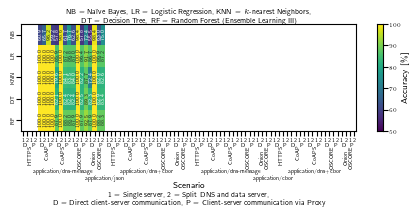

#### [SCHC](plots/accuracy_b1024_schc.pdf) (minimum: 62%)

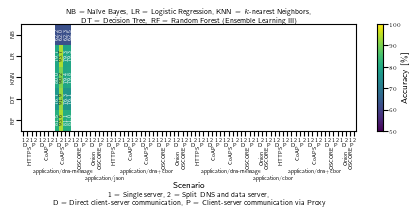

### Block Size 64

#### [“Ethernet”](plots/accuracy_b64_eth.pdf) (minimum: 81.1%)

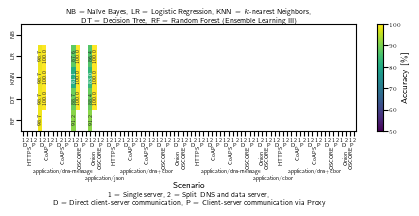

#### [SCHC](plots/accuracy_b64_schc.pdf) (minimum: nan%)

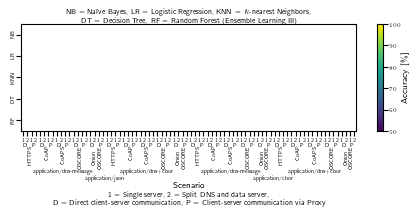

## Precision

### Block Size 1024

#### [“Ethernet”](plots/precision_b1024_eth.pdf) (minimum: 52.5%)

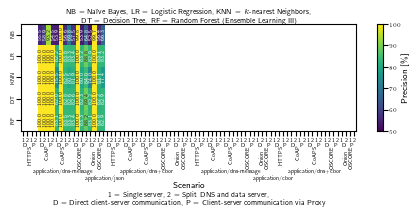

#### [SCHC](plots/precision_b1024_schc.pdf) (minimum: 50.7%)

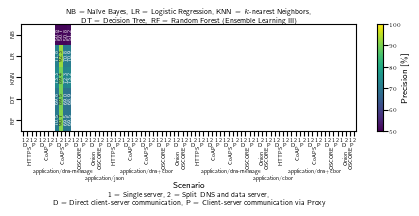

### Block Size 64

#### [“Ethernet”](plots/precision_b64_eth.pdf) (minimum: 74.2%)

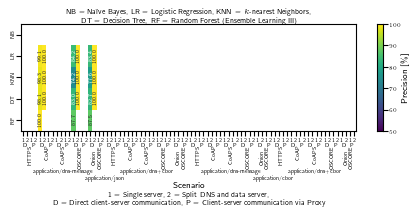

#### [SCHC](plots/precision_b64_schc.pdf) (minimum: nan%)

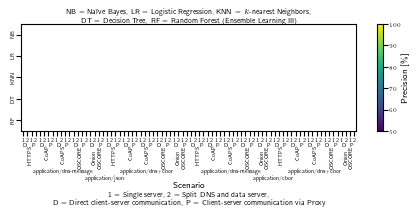

## Recall

### Block Size 1024

#### [“Ethernet”](plots/recall_b1024_eth.pdf) (minimum: 66.7%)

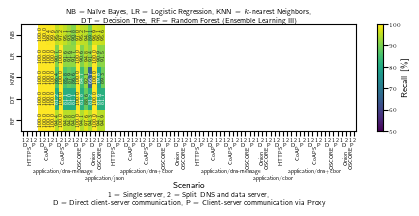

#### [SCHC](plots/recall_b1024_schc.pdf) (minimum: 48.8%)

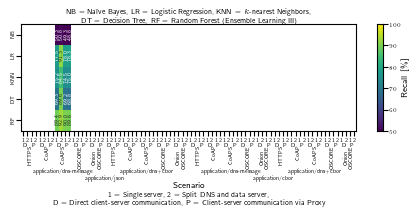

### Block Size 64

#### [“Ethernet”](plots/recall_b64_eth.pdf) (minimum: 67.5%)

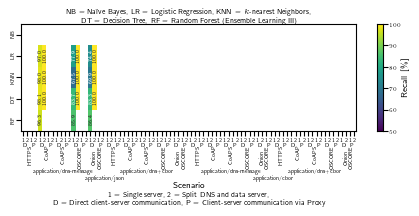

#### [SCHC](plots/recall_b64_schc.pdf) (minimum: nan%)

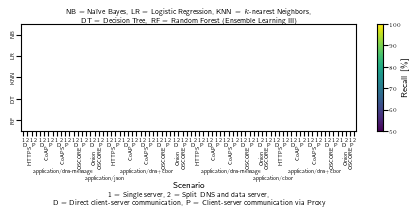

## $F_1$ score

### Block Size 1024

#### [“Ethernet”](plots/f1_score_b1024_eth.pdf) (minimum: 66.1%)

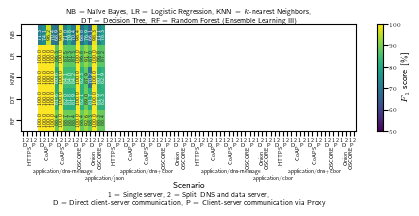

#### [SCHC](plots/f1_score_b1024_schc.pdf) (minimum: 49.9%)

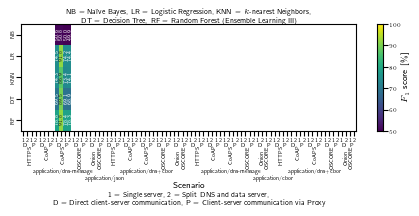

### Block Size 64

#### [“Ethernet”](plots/f1_score_b64_eth.pdf) (minimum: 70.7%)

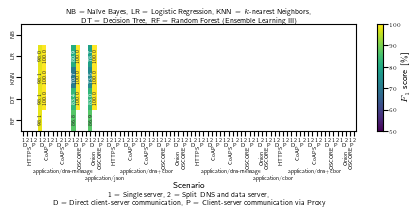

#### [SCHC](plots/f1_score_b64_schc.pdf) (minimum: nan%)

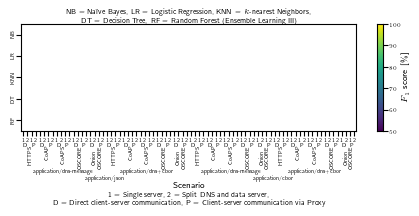

In [8]:
for metric in agg:
    display(Markdown(f"## {METRICS_READABLE[metric]}"))
    for blk in BLOCKWISE:
        display(Markdown(f"### Block Size {BLOCKWISE_READABLE[blk]}"))
        for l2 in LINK_LAYERS:
            df = pandas.DataFrame(
                agg[metric][l2, blk], index=[c.upper() for c in CLASSIFIERS]
            )
            df *= 100
            df = df.apply(
                lambda series: pandas.Series(
                    {
                        k: v if v is not None else numpy.nan
                        for k, v in series.to_dict().items()
                    }
                )
            )
            ax = seaborn.heatmap(
                df,
                annot=True,
                annot_kws={"size": 4, "rotation": 90, "ha": "center", "va": "center"},
                fmt=".1f",
                cbar_kws={"label": fr"{METRICS_READABLE[metric]} [\%]"},
                cmap="viridis",
                xticklabels=True,
                yticklabels=True,
                vmin=50,
                vmax=100,
            )
            xticks_num_nodes = ax.get_xticks()
            old_xticklabels = [l.get_text() for l in ax.get_xticklabels()]
            num_nodes = [int(re.sub(r".*-[pd]-(\d+)$", r"\1", x)) for x in old_xticklabels]
            ax.set_xticks(xticks_num_nodes, num_nodes, rotation=0, fontsize=4)
            xticks_route = []
            routes = []
            for i, xtick in enumerate(old_xticklabels):
                # Direct or via proxy
                if (i % 2) != 0:
                    continue
                xtick = re.sub(r".*-([pd])-\d+$", r"\1", xtick).upper()
                x = (xticks_num_nodes[i] + xticks_num_nodes[i + 1]) / 2
                ax.text(x, len(ax.get_yticks()) + 0.5, xtick, ha="center", va="top", fontsize=4)
            #for i, xtick in enumerate(old_xticklabels):
            #    # Link layer
            #    if (i % 4) != 0:
            #        continue
            #    xtick = int(re.sub(r".*-(\d+)-[pd]\d+$", r"\1", xtick))
            #    x = (xticks_num_nodes[i] + xticks_num_nodes[i + 3]) / 2
            #    ax.text(x, len(ax.get_yticks()) + 1.1, xtick, ha="center", va="top", fontsize=4)
            for i, xtick in enumerate(old_xticklabels):
                # Protocol
                if (i % 4) != 0:
                    continue
                xtick = PROTOCOLS_READABLE[re.sub(r".*-([^-]+)-[pd]-\d+$", r"\1", xtick)]
                x = (xticks_num_nodes[i] + xticks_num_nodes[i + 3]) / 2
                ax.text(x, len(ax.get_yticks()) + 0.7, xtick, ha="center", va="top", fontsize=4, rotation=90)
            for i, xtick in enumerate(old_xticklabels):
                # DNS format
                if (i % 20) != 0:
                    continue
                xtick = DNS_FORMAT_READABLE[re.sub(r".*-([^-]+)-[^-]+-[pd]-\d+$", r"\1", xtick)]
                x = (xticks_num_nodes[i] + xticks_num_nodes[i + 19]) / 2
                ax.text(x, len(ax.get_yticks()) + 1.75, xtick, ha="center", va="top", fontsize=4)
            for i, xtick in enumerate(old_xticklabels):
                # data format
                if (i % 40) != 0:
                    continue
                xtick = "application/" + re.sub(r"^([^-]+)-.*", r"\1", xtick)
                x = (xticks_num_nodes[i] + xticks_num_nodes[i + 39]) / 2
                ax.text(x, len(ax.get_yticks()) + 2.25, xtick, ha="center", fontsize=4)
            ax.text(len(xticks_num_nodes) / 2, len(ax.get_yticks()) + 2.85, "1 = Single server,\t2 = Split DNS and data server,\nD = Direct client-server communication,\tP = Client-server communication via Proxy", ha="center", va="top", fontsize="xx-small")
            seaborn.despine(fig=None, ax=None, top=False, right=False, left=False, bottom=False, offset=None, trim=False)
            ax.set_xlabel("Scenario", labelpad=28)
            ax.text(len(xticks_num_nodes) / 2, 0, f"NB = Naïve Bayes,\tLR = Logistic Regression,\tKNN = $k$-nearest Neighbors,\n{'SVM = State Vector Machine,\t' if 'svm' in CLASSIFIERS else ''}DT = Decision Tree,\tRF = Random Forest (Ensemble Learning III)", ha="center", va="bottom", fontsize="xx-small")
            filename = EVALUATION_DIR / "plots" / f"{metric}_b{BLOCKWISE_READABLE[blk]}_{LINK_LAYER_READABLE[l2]}.pdf"
            matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
            display(Markdown(f"#### [{LINK_LAYER_MORE_READABLE[LINK_LAYER_READABLE[l2]]}]({filename.relative_to(EVALUATION_DIR)}) (minimum: {df.min().min():.3g}%)"))
            matplotlib.pyplot.show()